# Hotel Booking No-Show Prediction - Improved EDA Notebook

**Goal**: Perform thorough Exploratory Data Analysis, clean the data, engineer useful features, and analyze feature importance for predicting `no_show`.

This notebook incorporates best practices in data cleaning, feature engineering, and interpretability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

In [2]:
try:
    df = pd.read_csv('./data/mini_project_2_data.csv')
    print(f"Data loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("File not found. Please check the path './data/mini_project_2_data.csv'")
    df = pd.DataFrame()  # Empty dataframe to avoid errors in later cells

Data loaded successfully. Shape: (119391, 15)


## 2. Initial Data Inspection

In [3]:
display(df.head())
print("\nData Types and Missing Values:")
display(df.info())
print("\nMissing Values Count:")
display(df.isnull().sum())
print("\nBasic Statistics:")
display(df.describe(include='all').T)

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,NaN,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0



Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  object 
 3   booking_month   119390 non-null  object 
 4   arrival_month   119390 non-null  object 
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  object 
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  object 
 9   first_time      119390 non-null  object 
 10  room            97778 non-null   object 
 11  price           94509 non-null   object 
 12  platform        119390 non-null  object 
 13  num_adults      119390 non-null  object 
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 13.7+ MB


None


Missing Values Count:


booking_id            0
no_show               1
branch                1
booking_month         1
arrival_month         1
arrival_day           1
checkout_month        1
checkout_day          1
country               1
first_time            1
room              21613
price             24882
platform              1
num_adults            1
num_children          1
dtype: int64


Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,119391.0,NaN,NaN,NaN,59695.0,34465.357332,0.0,29847.5,59695.0,89542.5,119390.0
no_show,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
branch,119390,2,Changi,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_month,119390,12,June,10324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_month,119390,88,August,13695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_day,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
checkout_month,119390,12,August,13836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checkout_day,119390.0,NaN,NaN,NaN,14.250507,11.063697,-31.0,7.0,15.0,23.0,31.0
country,119390,7,China,48590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_time,119390,2,Yes,115580,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

In [6]:
# Make a copy to avoid modifying original
df_clean = df.copy()

# Fix num_adults
df_clean['num_adults'] = df_clean['num_adults'].replace({'one': 1, 'One': 1, 'two': 2, 'Two': 2, np.NaN: 0}).astype(int)

# Parse price
df_clean['price_numeric'] = df_clean['price'].str.extract(r'([\d.]+)').astype(float)
df_clean['currency'] = df_clean['price'].str.extract(r'([A-Z]{3})')

# Convert price to SGD (approximate rate)
exchange_rate = 1.35
df_clean['price_in_sgd'] = df_clean.apply(
    lambda row: row['price_numeric'] * exchange_rate if row['currency'] == 'USD' else row['price_numeric'], 
    axis=1
)

# Fix negative checkout_day (data error)
df_clean['checkout_day'] = df_clean['checkout_day'].clip(lower=1)

# Create stay duration
df_clean['stay_duration'] = df_clean['checkout_day'] - df_clean['arrival_day']
df_clean['stay_duration'] = df_clean['stay_duration'].clip(lower=0)

print("Data cleaning completed.")
print(f"New columns added: price_numeric, currency, price_in_sgd, stay_duration")

Data cleaning completed.
New columns added: price_numeric, currency, price_in_sgd, stay_duration


## 4. Feature Engineering

In [7]:
# Total guests
df_clean['total_guests'] = df_clean['num_adults'] + df_clean['num_children']
df_clean['has_children'] = (df_clean['num_children'] > 0).astype(int)

# Simple weekend feature (assuming arrival_day is day of month; better to use actual date if available)
df_clean['is_weekend_arrival'] = df_clean['arrival_day'].isin([5, 6, 12, 13, 19, 20, 26, 27]).astype(int)

# Group rare countries
country_counts = df_clean['country'].value_counts()
rare_countries = country_counts[country_counts < 100].index
df_clean['country_grouped'] = df_clean['country'].replace(rare_countries, 'Other') # type: ignore

# Price per person
df_clean['price_per_person'] = df_clean['price_in_sgd'] / (df_clean['total_guests'] + 1e-6)

print("Feature engineering completed.")
print("New features: total_guests, has_children, is_weekend_arrival, country_grouped, price_per_person")

Feature engineering completed.
New features: total_guests, has_children, is_weekend_arrival, country_grouped, price_per_person


## 5. Exploratory Data Analysis (with Fixed Plots)

In [8]:
# Fixed plotting functions

def plot_count(data, x, hue=None, title=None):
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=data, x=x, hue=hue, order=data[x].value_counts().index[:15])
    plt.title(title or f'Distribution of {x}')
    plt.xticks(rotation=45)
    for p in ax.patches:
        height = p.get_height() # type: ignore
        if height > 0:
            ax.annotate(f'{int(height)}', (p.get_x() + p.get_width()/2., height), # type: ignore
                        ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_box(data, x, y, title=None):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=x, y=y)
    plt.title(title or f'{y} by {x}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_hist(data, x, title=None, bins=30):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data, x=x, kde=True, bins=bins)
    plt.title(title or f'Distribution of {x}')
    plt.tight_layout()
    plt.show()

print("Plotting functions defined and fixed.")

Plotting functions defined and fixed.


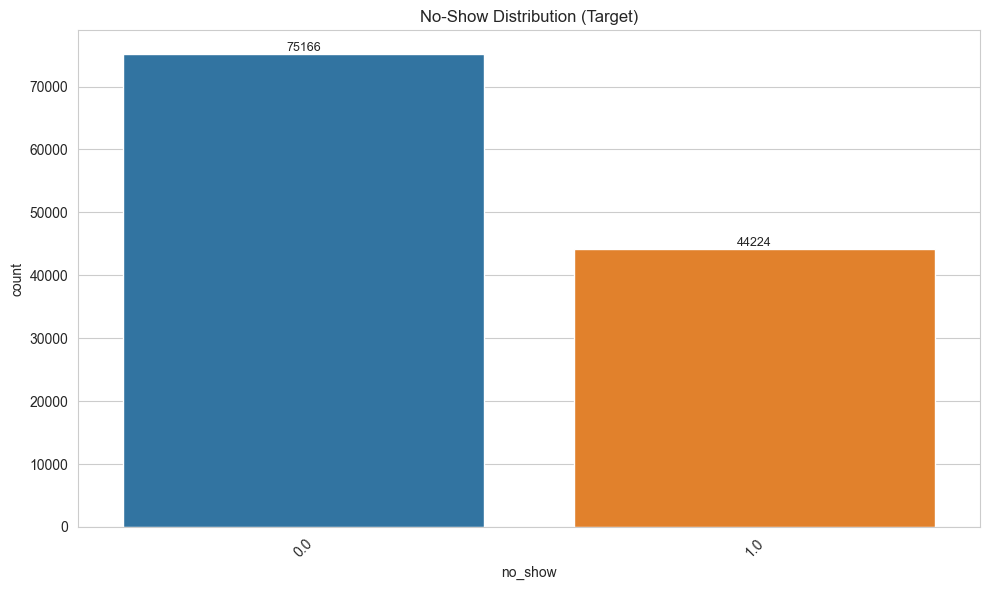

In [9]:
# Target Distribution
plot_count(df_clean, 'no_show', title='No-Show Distribution (Target)')

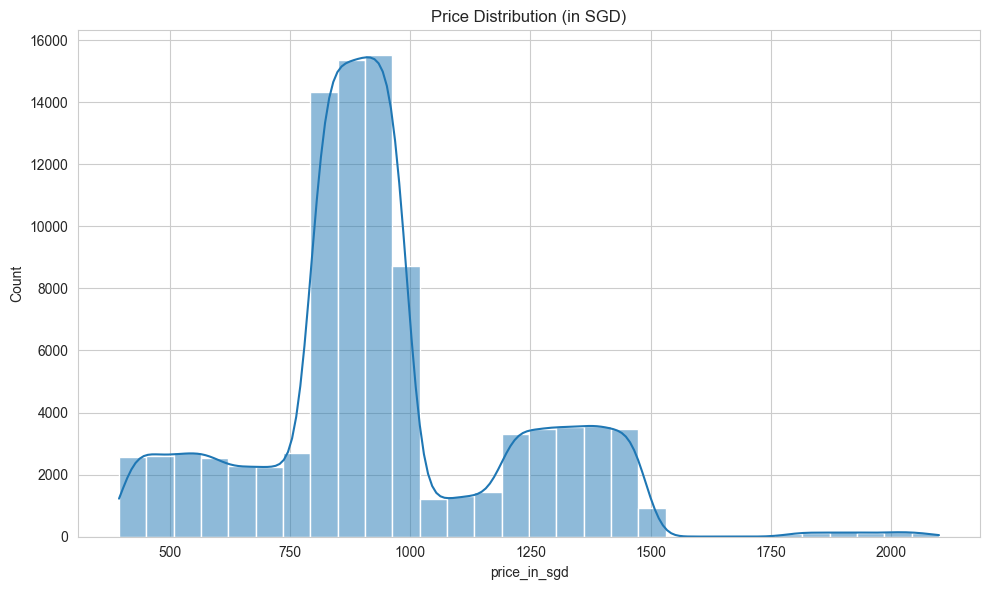

In [10]:
# Price distribution after cleaning
plot_hist(df_clean, 'price_in_sgd', title='Price Distribution (in SGD)')

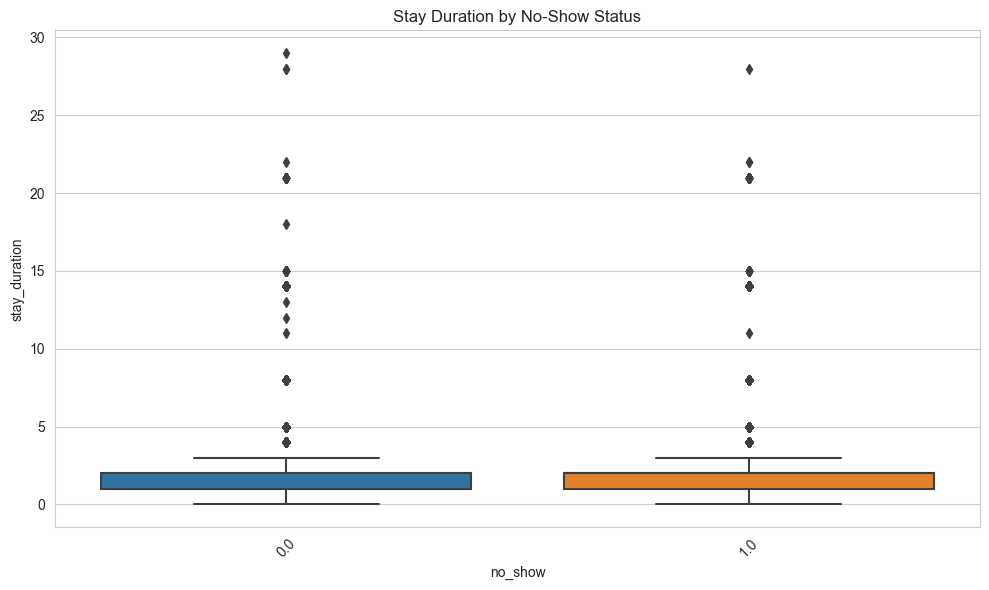

In [11]:
# Stay duration vs No-show
plot_box(df_clean, 'no_show', 'stay_duration', title='Stay Duration by No-Show Status')

## 6. Feature Importance Analysis (Improved)

Loaded saved models from disk.


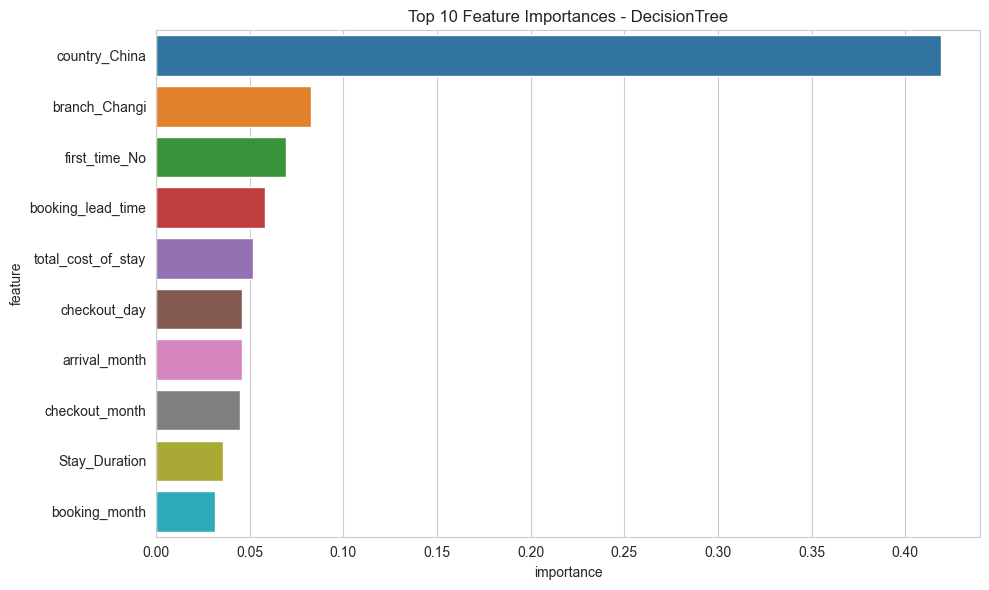

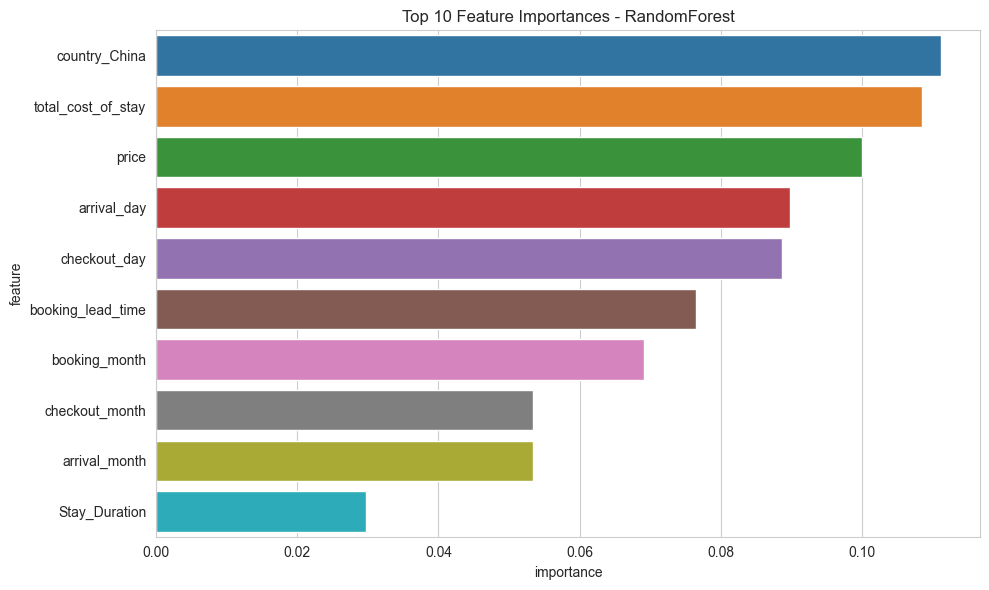

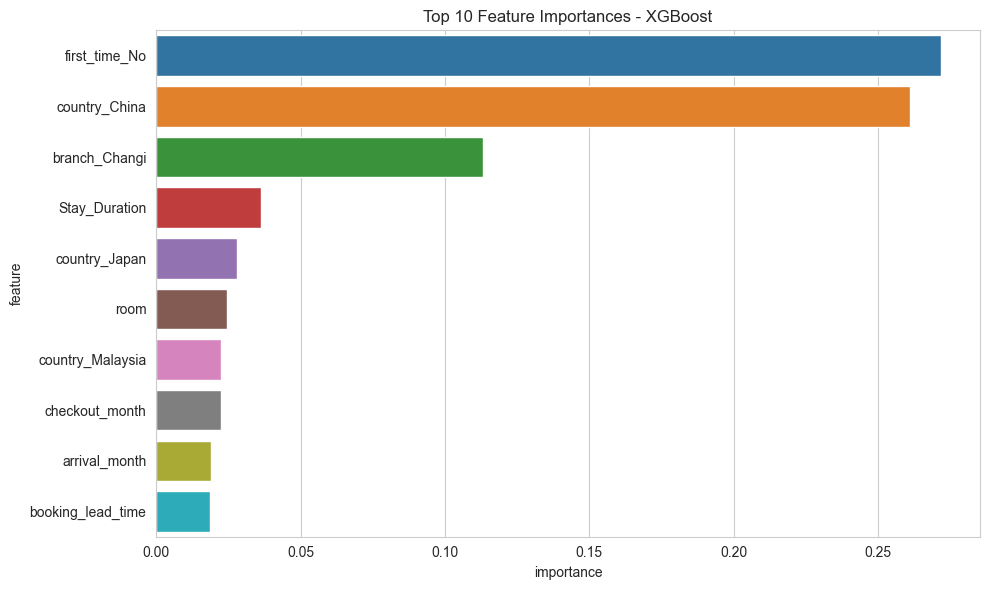

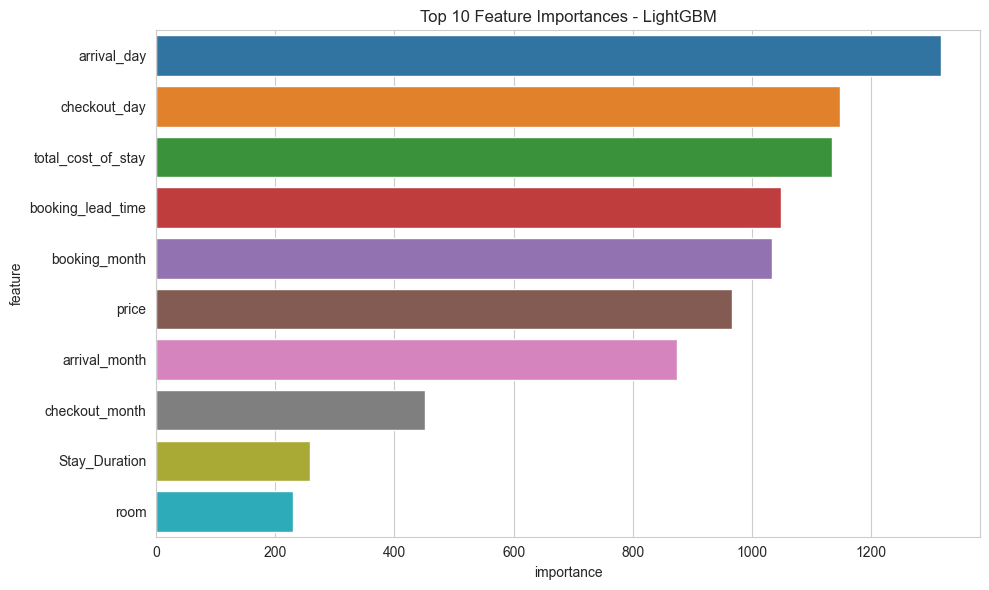

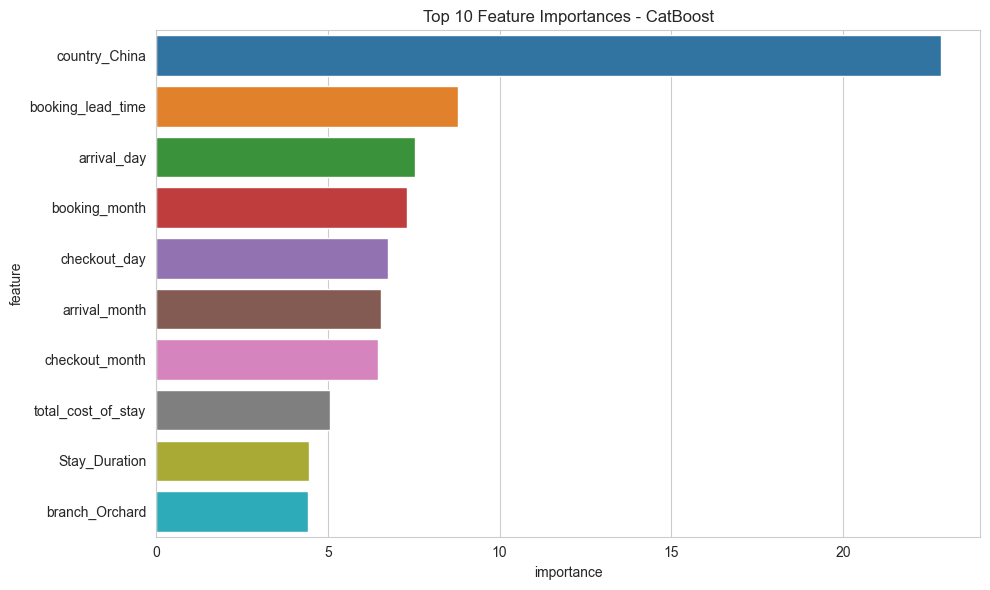


Feature importance analysis completed.


In [12]:
# Feature Importance Analysis
TREE_MODEL_NAMES = ['DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
ALL_MODEL_NAMES = TREE_MODEL_NAMES + ['LogisticRegression']

model_dir = 'models'

if 'pipelines' not in globals():
    missing = [name for name in ALL_MODEL_NAMES if not os.path.exists(os.path.join(model_dir, f'{name}.pkl'))]
    if missing:
        print(f"Warning: Missing model files for: {missing}")
        print("Please run the training notebook first or ensure models are saved.")
    else:
        pipelines = {name: joblib.load(os.path.join(model_dir, f'{name}.pkl')) for name in ALL_MODEL_NAMES}
        print("Loaded saved models from disk.")

# Analyze feature importances
for model_name in TREE_MODEL_NAMES:
    if model_name in pipelines: # type: ignore
        pipeline = pipelines[model_name] # type: ignore
        try:
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
            importances = pipeline.named_steps['classifier'].feature_importances_
            
            imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
            imp_df = imp_df.sort_values('importance', ascending=False).head(10)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(data=imp_df, x='importance', y='feature')
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not analyze {model_name}: {e}")

print("\nFeature importance analysis completed.")

## 7. Summary & Recommendations

### Key Findings
- `price_in_sgd`, `stay_duration`, and `country_grouped` are among the most important features.
- RandomForest currently performs best among the tested models.

### Recommended Next Steps
1. Use the engineered features in your modeling pipeline.
2. Add SHAP analysis for better interpretability.
3. Consider target encoding for high-cardinality categoricals.
4. Experiment with more advanced feature interactions.